#K Means Clustering Algorithms Implementation

In [46]:
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs

In [47]:
import pandas as pd
import numpy as np
%matplotlib inline

In [48]:
X,y = make_blobs(n_samples = 1000, centers = 3, n_features = 2, random_state = 23)

In [49]:
X.shape

(1000, 2)

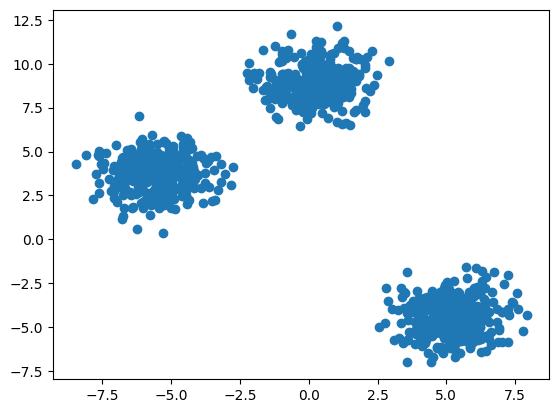

In [50]:
plt.scatter(X[:,0],X[:,1])

In [51]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,y ,test_size = 0.33, random_state = 42
)

In [52]:
from sklearn.cluster import KMeans

In [53]:
## Manual Process
## Elbow Method to select the k value

wcss = []
for k in range(1,11):
    kmeans = KMeans(n_clusters = k, init = "k-means++")
    kmeans.fit(X_train)
    wcss.append(kmeans.inertia_)

In [54]:
wcss

[34827.57682552022,
 7935.4372861454185,
 1319.2730531585607,
 1170.876115631399,
 993.4316837281525,
 856.5077850618316,
 765.5996305837436,
 715.6458848397707,
 633.4588755226765,
 607.754504707172]

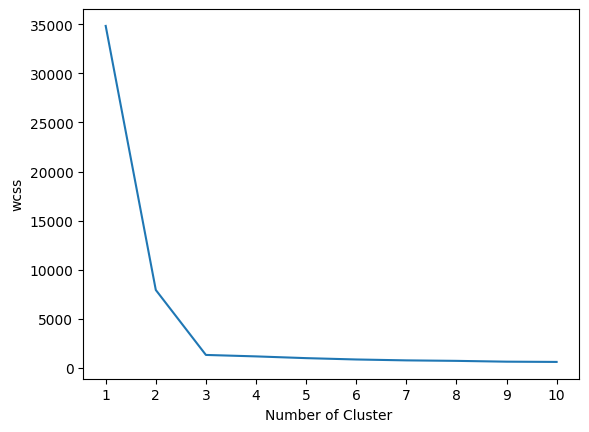

In [55]:
## plot elbow curve
plt.plot(range(1,11),wcss)
plt.xticks(range(1,11))
plt.xlabel("Number of Cluster ")
plt.ylabel("wcss")
plt.show()

In [56]:
kmeans = KMeans(n_clusters = 3, init = "k-means++")

In [57]:
y_labels = kmeans.fit_predict(X_train)

In [61]:
y_test_labels = kmeans.predict(X_test)

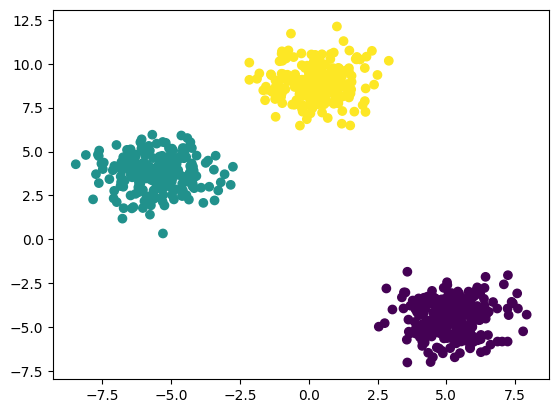

In [62]:
plt.scatter(X_train[:,0], X_train[:,1], c=y_labels)

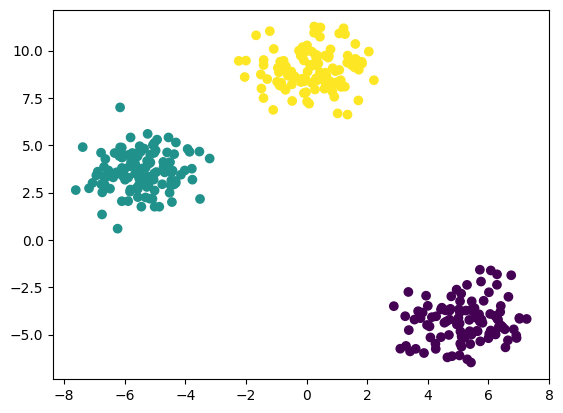

In [63]:
plt.scatter(X_test[:,0], X_test[:,1], c= y_test_labels)

In [64]:
##knee locator
!pip install kneed

Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 25.0.1 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


In [66]:
from kneed import KneeLocator

In [68]:
kl = KneeLocator(range(1,11), wcss, curve = 'convex', direction = "decreasing")

In [69]:
kl.elbow

np.int64(3)

In [73]:
## Performance metrics
## silhoutte score 

from sklearn.metrics import silhouette_score

In [75]:
silhouette_coefficeint =[]

for k in range(2,11):
    kmeans = KMeans(n_clusters =k, init= "k-means++")
    kmeans.fit(X_train)
    score = silhouette_score(X_train, kmeans.labels_)
    silhouette_coefficeint.append(score)

In [76]:
silhouette_coefficeint

[0.7281443868598331,
 0.8071181203797672,
 0.6357733426488265,
 0.4783511740341074,
 0.3321994964555899,
 0.3341312391102273,
 0.315917457312196,
 0.34416710752620966,
 0.33771371745805256]

ValueError: x and y must have same first dimension, but have shapes (10,) and (9,)

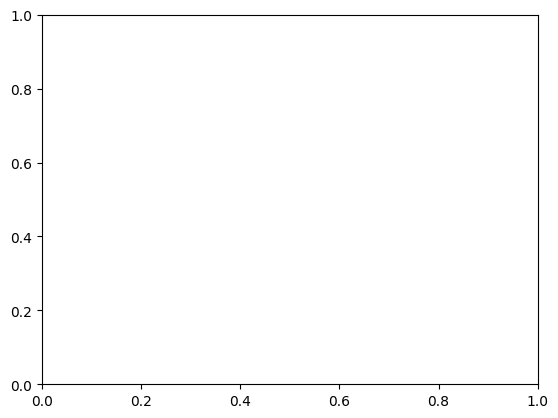

In [78]:
plt.plot(range(1,11),silhouette_coefficeint)
plt.xticks(range(1,11))
plt.xlabel("Number of Cluster ")
plt.ylabel("silhouette_coefficeint")
plt.show()